# TASK #1: UNDERSTAND THE PROBLEM STATEMENT AND BUSINESS CASE


In [2]:
# In this hands-on project, we will train machine learning and deep learning models to predict the % of Silica
# Concentrate in the Iron ore concentrate per minute. This project could be practically used in the mining industry
# to get the % Silica Concentrate at much faster rate compared to traditional methods. Freeport-McMoRan is one of
# the largest mining companies in US. They have made use of custom-built AI models to boost the output in their
# mining facilities.

# By leveraging past 3+ years data, AI has helped mining facility sustain a faster production pace with no loss of
# efficiency. Efficiency has been improved by performing operational tweaks to boost output (E.x. copper production
# could be increased if the mill was fed with more ore per minute.)

# Source: https://www.mckinsey.com/industries/metals-and-mining/how-we-help-clients/mining

In [3]:
# These are the 3 applications in which mining companies leverage the power of Artificial Intelligence and Machine
# Learning.

    # Mineral Explorations
    # Autonomous Drillers
    # Minerals sorting

#Source: https://www.forbes.com/sites/bernardmarr/2018/09/07/the-4th-industrial-revolution-how-mining-companies-are-using-ai-machine-learning-and-robots/#fcde6c6497e5

# TASK #2: IMPORT LIBRARIES/DATASETS AND PERFORM DATA EXPLORATION 

In [5]:
# In this task, let's go ahead and import all our key libraries and datasets and also perform data exploration.

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile
from jupyterthemes import jtplot
jtplot.style(theme='monokai', context='notebook', ticks=True, grid=False) 
# setting the style of the notebook to be monokai theme  
# this line of code is important to ensure that we are able to see the x and y axes clearly
# If you don't run this code line, you will notice that the xlabel and ylabel on any plot is black on black and it will be hard to see them. 


In [7]:
# Read our mining data
mining_df = pd.read_csv('mining_data.csv')

In [8]:
# View our mining data
mining_df

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,55.20,16.98,3196.680000,542.694333,396.284000,10.158367,1.668070,249.796333,250.275667,248.668000,...,250.547000,464.978667,490.450333,443.465000,442.856333,438.782333,452.248333,466.300667,67.06,1.11
1,55.20,16.98,3213.673333,540.649333,397.949333,10.156600,1.664973,249.536000,250.752000,250.968333,...,249.807000,445.001000,362.894667,442.748333,471.045333,445.239667,443.630667,426.921667,67.06,1.11
2,55.20,16.98,3180.080000,535.929333,397.305000,10.154800,1.661877,249.576000,250.279667,251.001333,...,249.686667,443.574667,478.916333,432.779333,437.401667,441.761000,490.824667,478.046667,67.06,1.11
3,55.20,16.98,3196.713333,535.102000,397.010667,10.153067,1.658780,249.380333,248.799333,250.241333,...,249.926333,440.731333,488.994000,452.461333,439.572667,434.027333,457.083667,458.815667,67.06,1.11
4,55.20,16.98,3111.723333,532.735000,395.263667,10.151300,1.655680,249.426667,252.209667,249.243333,...,249.975667,445.851667,418.860000,462.936667,454.948333,453.571667,446.831667,426.600000,67.06,1.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245695,49.75,23.20,2961.490000,452.658667,381.784667,9.615990,1.654507,300.351000,295.703667,298.312667,...,321.464444,404.055667,523.933667,880.286833,331.448333,500.245000,424.037667,400.798000,64.27,1.71
245696,49.75,23.20,2851.376667,470.843333,384.250000,9.617760,1.654413,299.978667,304.478333,301.176667,...,335.351222,417.104667,548.184333,883.347000,388.821000,482.577333,338.373000,371.803333,64.27,1.71
245697,49.75,23.20,2729.876667,463.040667,383.073667,9.619523,1.654070,302.416667,299.060000,299.929000,...,291.529000,386.853000,546.765000,870.141667,435.600333,488.983667,420.578667,366.426333,64.27,1.71
245698,49.75,23.20,2698.756667,460.303667,384.490667,9.620873,1.653653,302.603000,299.953333,299.483667,...,285.945000,395.502667,443.776333,872.247333,416.832667,495.943333,437.163000,417.842667,64.27,1.71


In [9]:
# Now we have our dataset. The first observation that we will get out of this data is that it is quite large, having
# 245,700 rows and 23 columns. So we have % iron feed, % silica feed, we have starch flow, we have amina flow, we
# have ore pulp flow, ore pulp ph. There are actually so many columns in here so note that the understanding of
# the details of all these different columns are beyond our scope of this project. What we just want is to predict
# the % silica concentrate.

In [10]:
# Show the datatypes of our data
mining_df.dtypes

% Iron Feed                     float64
% Silica Feed                   float64
Starch Flow                     float64
Amina Flow                      float64
Ore Pulp Flow                   float64
Ore Pulp pH                     float64
Ore Pulp Density                float64
Flotation Column 01 Air Flow    float64
Flotation Column 02 Air Flow    float64
Flotation Column 03 Air Flow    float64
Flotation Column 04 Air Flow    float64
Flotation Column 05 Air Flow    float64
Flotation Column 06 Air Flow    float64
Flotation Column 07 Air Flow    float64
Flotation Column 01 Level       float64
Flotation Column 02 Level       float64
Flotation Column 03 Level       float64
Flotation Column 04 Level       float64
Flotation Column 05 Level       float64
Flotation Column 06 Level       float64
Flotation Column 07 Level       float64
% Iron Concentrate              float64
% Silica Concentrate            float64
dtype: object

In [11]:
# We can see that all the columns has a datatype of float64 indicating that data type can actually handle fractional
# numbers.

In [12]:
# check the number of null elements in the dataframe
mining_df.isnull().sum()

% Iron Feed                     0
% Silica Feed                   0
Starch Flow                     0
Amina Flow                      0
Ore Pulp Flow                   0
Ore Pulp pH                     0
Ore Pulp Density                0
Flotation Column 01 Air Flow    0
Flotation Column 02 Air Flow    0
Flotation Column 03 Air Flow    0
Flotation Column 04 Air Flow    0
Flotation Column 05 Air Flow    0
Flotation Column 06 Air Flow    0
Flotation Column 07 Air Flow    0
Flotation Column 01 Level       0
Flotation Column 02 Level       0
Flotation Column 03 Level       0
Flotation Column 04 Level       0
Flotation Column 05 Level       0
Flotation Column 06 Level       0
Flotation Column 07 Level       0
% Iron Concentrate              0
% Silica Concentrate            0
dtype: int64

In [13]:
# What we get is a bunch of zeros, indicating that we do not have any missing element in any of the 245,700 rows. If
# we have any missing element, we should be able to see any numbers here, maybe like number 5, 6, or 7, indicating
# how many missing elements have been detected.

- **What is the average % Silica concentrate?**
- **What is the maximum % Iron concentrate?**

In [15]:
# Show the statistical summary of our data
mining_df.describe()

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,...,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000
mean,56.294974,14.651438,2869.241181,488.144186,397.577332,9.767534,1.680348,280.166032,277.172893,281.097236,...,290.774336,520.242050,522.648563,531.355055,420.306805,425.237994,429.927646,421.006767,65.049435,2.327228
std,5.158958,6.808961,1187.990184,90.736360,9.468496,0.387036,0.069213,29.616570,29.936823,28.537193,...,28.158596,130.389539,127.450562,150.614529,90.566437,83.601851,85.320602,83.736727,1.118479,1.125623
min,42.740000,1.310000,0.074147,241.699632,376.272600,8.753370,1.519829,175.666333,175.923177,176.471917,...,186.074077,149.451600,211.266111,126.352031,162.293185,167.139620,161.485667,175.908240,62.050000,0.600000
25%,52.670000,8.940000,2073.322500,432.204667,395.212583,9.527158,1.647197,250.268667,250.367333,250.693667,...,263.524333,413.516320,442.291000,410.134583,356.440167,357.074583,358.078583,356.567833,64.370000,1.440000
50%,56.080000,13.850000,2994.311667,504.510667,399.354833,9.797963,1.697560,299.418000,297.433000,299.048333,...,299.350833,492.971167,496.380667,494.859500,410.511667,408.022833,419.931167,410.043333,65.210000,2.000000
75%,59.720000,19.600000,3712.951667,553.479083,402.458750,10.037833,1.728257,300.127333,300.435000,300.308667,...,301.239667,594.960083,595.989167,601.060000,486.533417,485.580833,490.725500,475.922283,65.860000,3.010000
max,65.780000,33.400000,6295.130657,739.422405,418.625439,10.808046,1.853229,372.387588,369.550000,359.948635,...,370.190800,862.197932,828.593000,886.820204,680.019967,675.571459,698.621871,659.618696,68.010000,5.530000


In [16]:
# The average % Silica concentrate is 2.33%, while the maximum % Iron concentrate is 68%.

# TASK #3: PERFORM DATA VISUALIZATION

In [18]:
# In this task, let's perform data visualization. First, let's plot the histogram for all the different columns that
# we have in the data, using 30 bins.

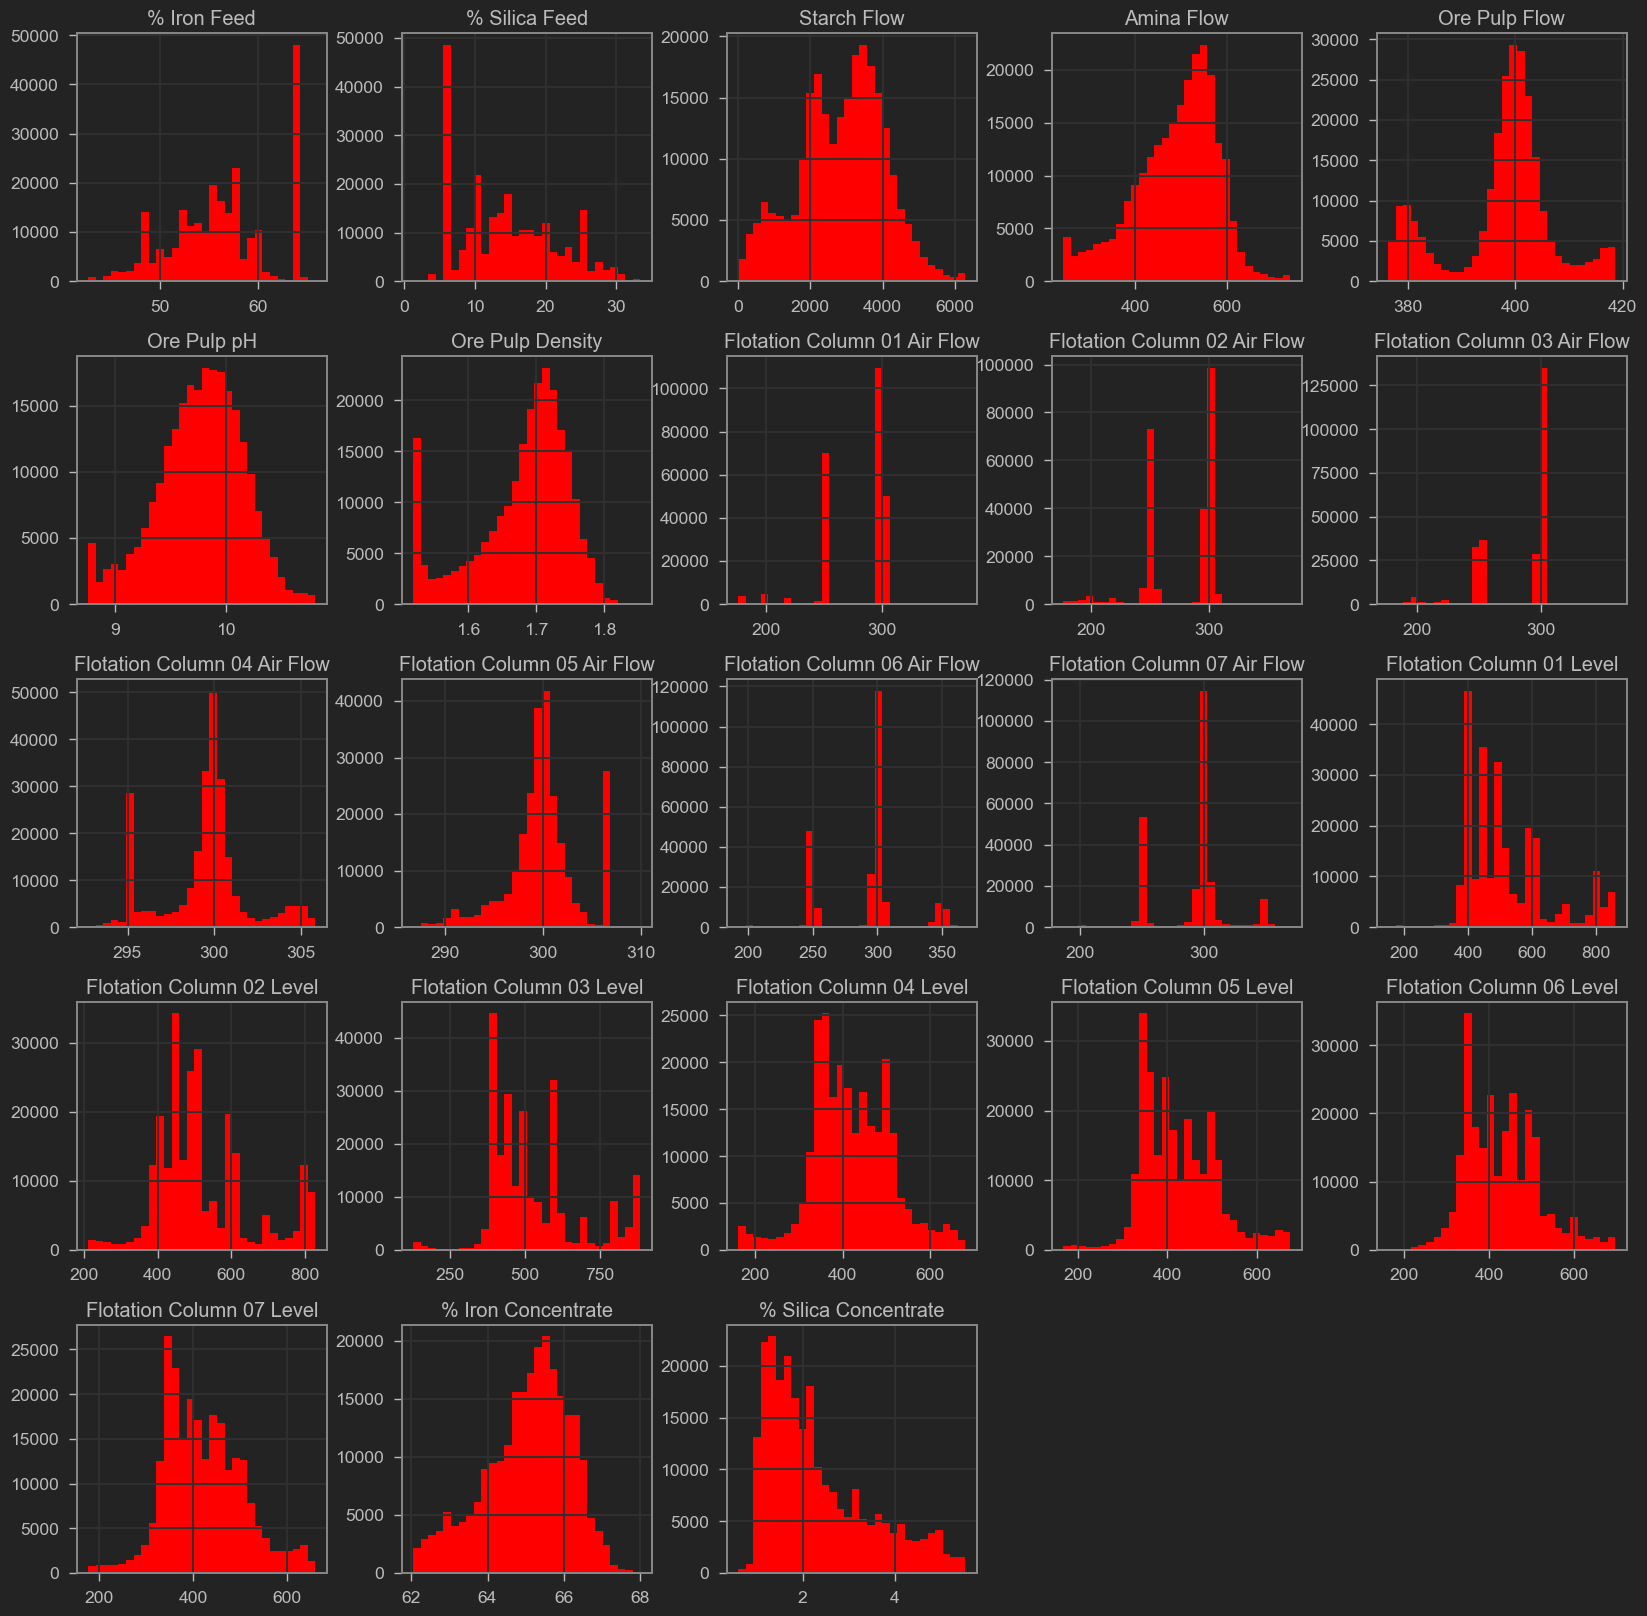

In [19]:
mining_df.hist(bins = 30, figsize=(20,20), color = 'red')
plt.show()

In [20]:
# Looking at the %iron concentrate, we have a lot of data points that actually lies between 64-66, and tapers off as
# we increase. The %iron concentrate to beyond 66 or below 62 as well. Also, we have the distribution of the
# % Silica concentrate, here we have the % silica feed as well.

In [21]:
# Obtain the correlation matrix
mining_df.corr()

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
% Iron Feed,1.000000,-0.971837,0.028644,-0.088595,0.164676,0.007496,-0.125583,-0.062448,-0.170716,-0.062318,...,-0.016722,0.029619,0.020928,0.015189,0.016346,0.023571,0.003910,0.026100,0.055526,-0.077108
% Silica Feed,-0.971837,1.000000,-0.016489,0.079065,-0.154508,0.007953,0.104567,0.091833,0.183953,0.084325,...,0.046193,-0.038417,-0.037113,-0.022653,-0.034534,-0.044270,-0.020568,-0.047079,-0.044292,0.072778
Starch Flow,0.028644,-0.016489,1.000000,0.261934,0.044926,0.269135,0.231530,0.195538,0.192244,0.187602,...,0.202817,-0.302567,-0.286336,-0.309177,-0.013037,-0.057417,-0.077105,-0.039584,0.071303,-0.068008
Amina Flow,-0.088595,0.079065,0.261934,1.000000,0.219162,0.124254,0.659461,0.111994,0.124490,0.102632,...,0.081561,-0.270753,-0.236452,-0.288484,-0.183739,-0.215334,-0.209496,-0.171384,-0.111045,0.157644
Ore Pulp Flow,0.164676,-0.154508,0.044926,0.219162,1.000000,0.121256,0.012571,-0.141215,-0.122322,-0.144232,...,-0.146904,-0.008877,-0.008335,-0.055890,-0.010212,0.002158,-0.018051,0.017185,0.085098,0.008519
Ore Pulp pH,0.007496,0.007953,0.269135,0.124254,0.121256,1.000000,0.115073,0.163433,0.146264,0.193887,...,0.178322,-0.166525,-0.154391,-0.140251,0.046933,0.013095,-0.079157,0.019193,0.192705,-0.147550
Ore Pulp Density,-0.125583,0.104567,0.231530,0.659461,0.012571,0.115073,1.000000,-0.004695,0.026413,-0.031237,...,-0.052655,-0.112201,-0.093542,-0.149823,-0.089066,-0.142675,-0.105346,-0.087454,0.015116,0.047413
Flotation Column 01 Air Flow,-0.062448,0.091833,0.195538,0.111994,-0.141215,0.163433,-0.004695,1.000000,0.854298,0.955256,...,0.658199,-0.443870,-0.428294,-0.372533,-0.062665,-0.092254,-0.125196,-0.112074,0.099239,-0.219698
Flotation Column 02 Air Flow,-0.170716,0.183953,0.192244,0.124490,-0.122322,0.146264,0.026413,0.854298,1.000000,0.866927,...,0.592888,-0.437313,-0.428303,-0.368913,-0.075833,-0.112465,-0.124478,-0.114693,0.059709,-0.169029
Flotation Column 03 Air Flow,-0.062318,0.084325,0.187602,0.102632,-0.144232,0.193887,-0.031237,0.955256,0.866927,1.000000,...,0.661261,-0.443454,-0.423836,-0.365800,-0.047216,-0.064355,-0.105673,-0.086448,0.100888,-0.219593


In [22]:
# Here we have the correlation matrix, and essentially if we have 2 variables that are positively correlated or
# directly correlated with each other, then you should be able to see the number 1 correlation. If we have 2
# variables that are inversely correlated with each other, then we get the value for the correlation of -1. We have
# every single column that we have in our data, in the diagonal values we have all equals to 1 meaning that each
# variable perfectly correlated to itself. To have a better view of this, let's visualize this by correlation 
# matrix.

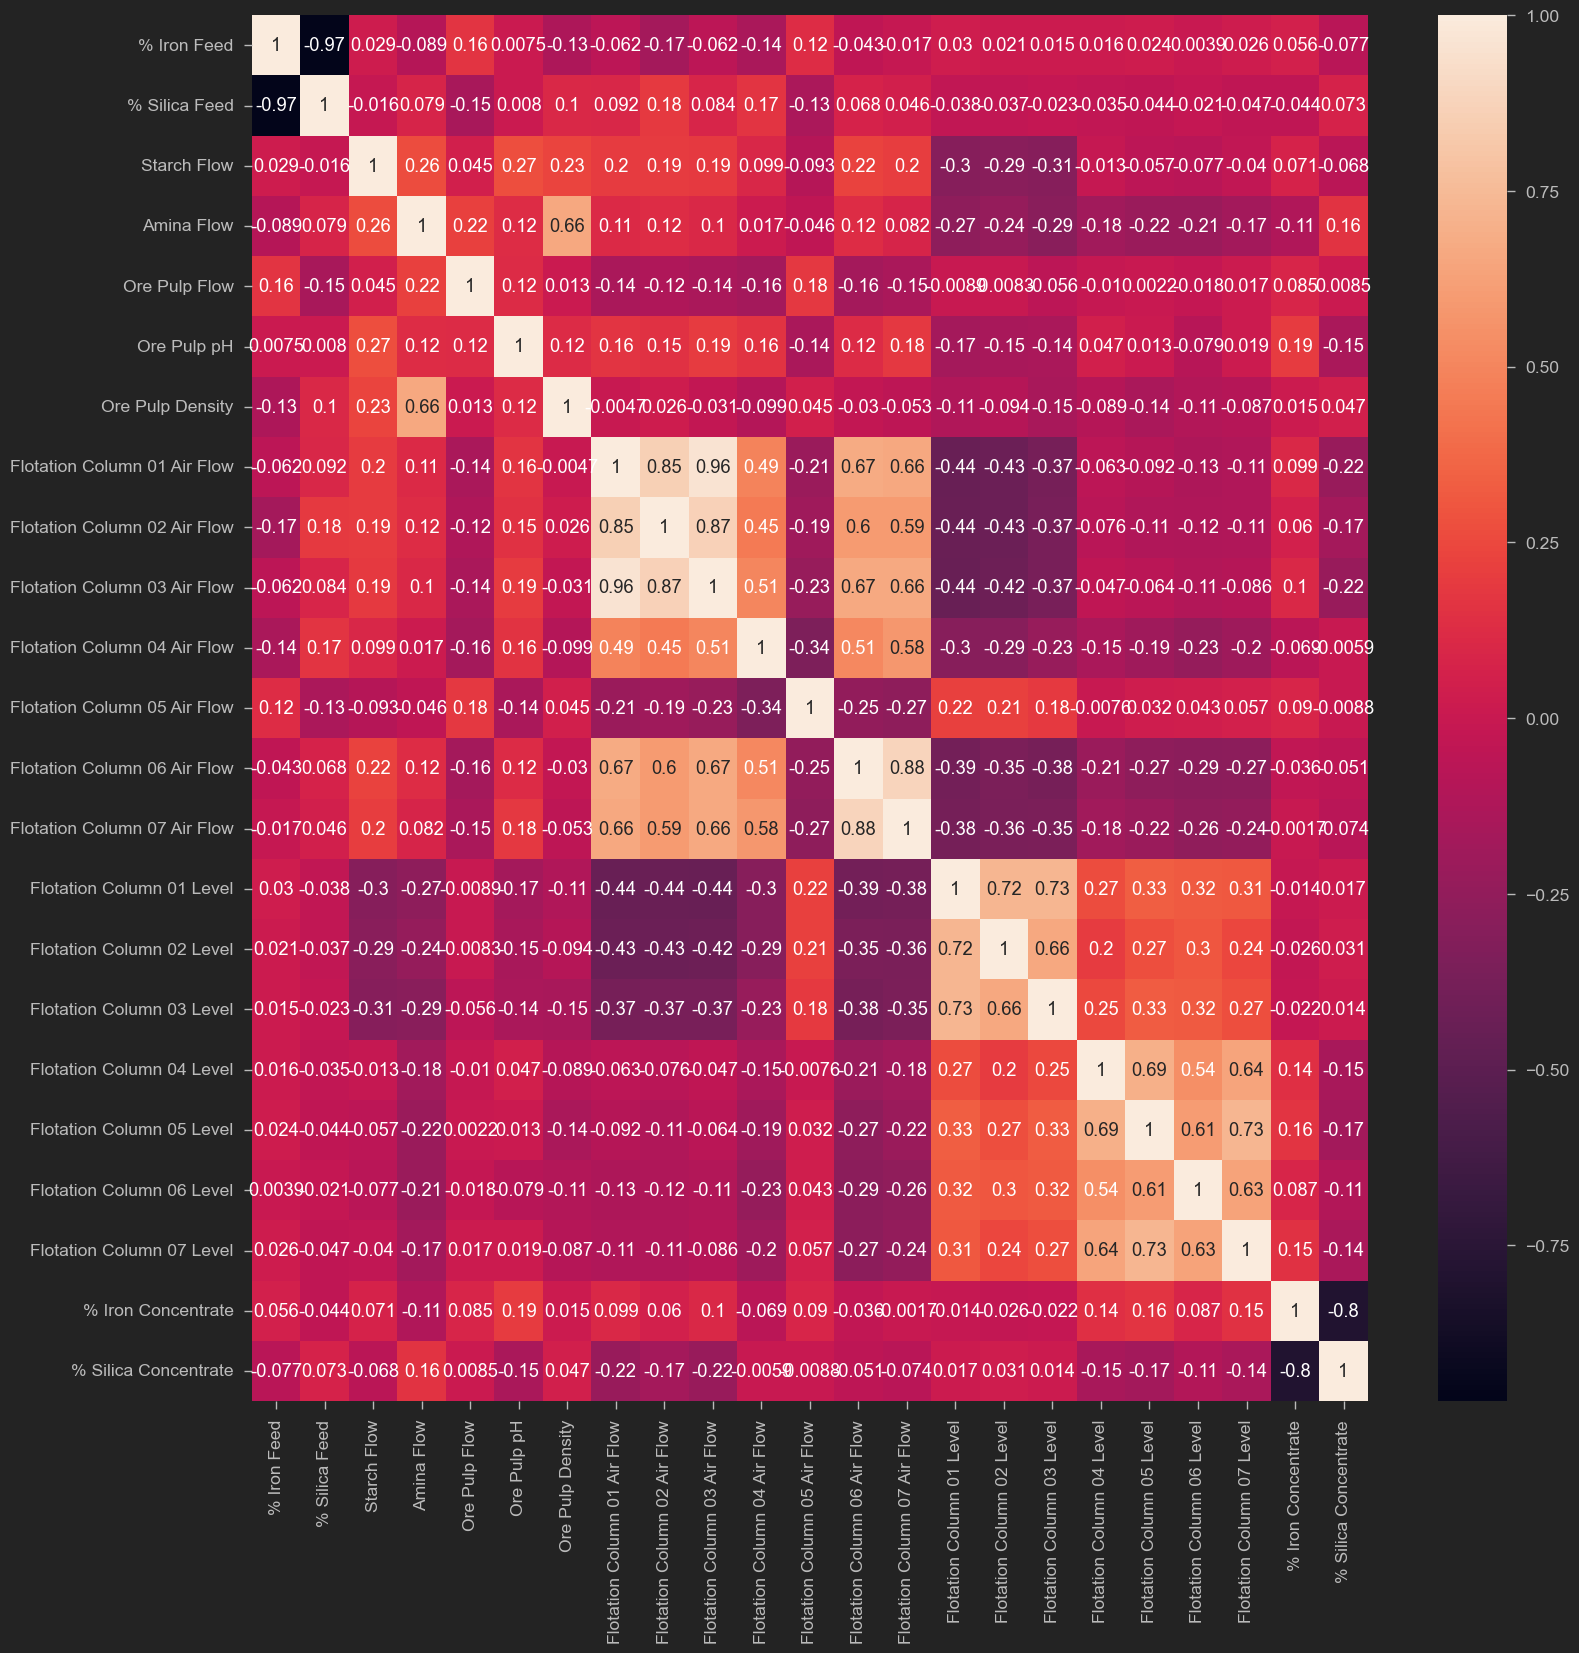

In [23]:
plt.figure(figsize = (18,18))
sns.heatmap(mining_df.corr(), annot = True)
plt.show()
# From this pair plot, we can infer that there is a relationship between iron feed and silica feed 
# Also, a relationship between silica concentrate and iron concentrate.

In [24]:
# As we can see, if we have a light color or white color, that indicates perfect positive correlation of 1. If we
# have any variables or cells that are dark, that means we have perfect negative correlation like -1. Anything in
# between all the different shades of the colors indicate different value that ranges between -1 and 1. We can see
# also that there is a strong negative relationship between the iron feed and percentage silica feed, let's explore
# more on that leter on. But essentially, just by looking at the heatmap, we can infer a lot of information about
# how variables are correlated with each other.

- **Plot the scatterplot between % Silica concentrate and % Iron concentrate and try to relate to the correlation matrix**
- **Plot the scatterplot between % Iron Feed and % Silica Feed and try to relate to the correlation matrix**

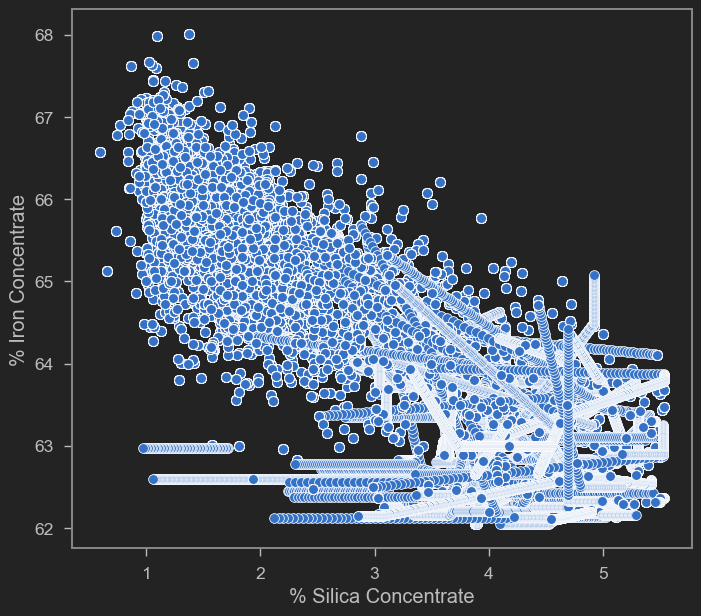

In [26]:
sns.scatterplot(x = mining_df['% Silica Concentrate'], y = mining_df['% Iron Concentrate'])
plt.show()

In [27]:
# What we see here is as % silica concentrate tends to increase, we can find that the % iron concentrate tend to
# decrease, meaning that there is a negative correlation between these two. Confirming from our correlation matrix
# since they have -0.8 correlation, inverse relationship.

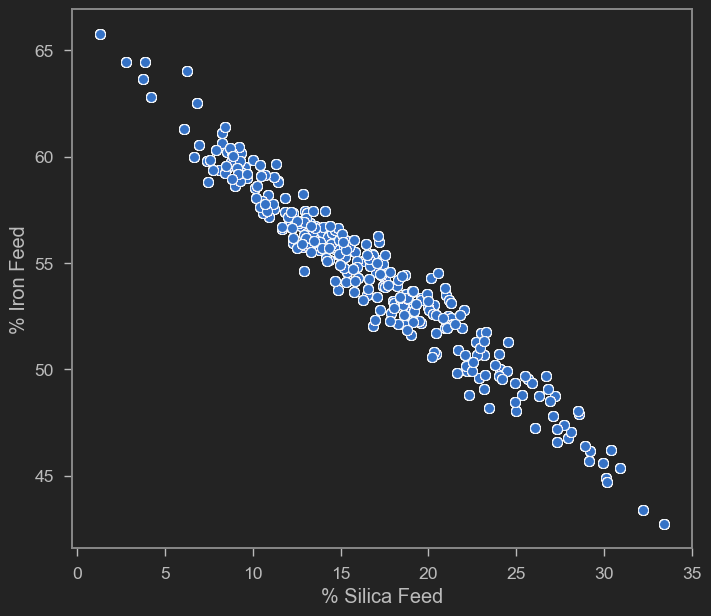

In [28]:
sns.scatterplot(x = mining_df['% Silica Feed'], y = mining_df['% Iron Feed'])
plt.show()

In [29]:
# So now, as the % iron feed tend to increase, we can find that the % silica feed tend to go down or tend to
# decrease. And that's essentially what we can see in our correlation matrix as well, having -0.97 correlation.

# TASK #4: PREPARE THE DATA BEFORE MODEL TRAINING

In [31]:
# Let's do the final step before we go ahead and train our machine learning model followed by our deep artificial
# neural network model later on.

In [32]:
# Create independent and dependent sets
# Take the output as y and separate from all the input as X
df_iron = mining_df.drop(columns = '% Silica Concentrate')
df_iron_target = mining_df['% Silica Concentrate']

In [33]:
df_iron.shape

(245700, 22)

In [34]:
df_iron_target.shape

(245700,)

In [35]:
# Convert to numpy array
df_iron = np.array(df_iron)
df_iron_target = np.array(df_iron_target)

In [36]:
# Reshaping the array
df_iron_target = df_iron_target.reshape(-1,1)
df_iron_target.shape

(245700, 1)

In [37]:
# Basically, we call this batch format. We are essentially feeding in the data in a batch format. Its still 1
# column.

In [38]:
# Scaling the data before feeding the model
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_x = StandardScaler()
X = scaler_x.fit_transform(df_iron)

scaler_y = StandardScaler()
y = scaler_y.fit_transform(df_iron_target)

In [39]:
# Spliting the data in to test and train sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [40]:
X_test.shape

(49140, 22)

In [41]:
X_train.shape

(196560, 22)

# TASK #5: TRAIN AND EVALUATE A LINEAR REGRESSION MODEL

In [43]:
# In simple linear regression, we predict the value of one variable Y based on another variable X. X is called the
# independent variable and Y is called the dependent variable. Why do we call it simple? Because it examines
# the relation between two variables only. Why do we call it linear? when the independent variable increases (or
# decreases), the dependent variable increases (or decreases) in a linear fashion. Note that in this project, we
# are not going to apply simple linear regression. Instead, we're gonna apply multiple linear regression because we
# have multiple inputs and only one output. Now, what we are trying to do here is to find the best fit line that
# can go through our data. So, if you can remember from any statistics course or any math course, is that the
# straight line equation is Y = b + mx, having X as our independent variable, and y is the dependent variable, m is
# the slope of the line which is (delta y)/(delta x), and b is simply the y-intercept, or how high or low is the
# line from the origin. The goal is to obtain a relationship (model) between X and y. We're trying to find the
# optimal value for m and b.

In [44]:
# Multiple Linear Regression examines relationship between more than two variables. Recall that simple linear
# regression is a statistical model that examines linear relationship between two variables only. In multiple linear
# regression, we want to do the same but we want to expand and have multiple inputs(refer to the equation below).
# Instead of only obtaining the m and b parameters, we want to obtain now many coefficients. Each independent
# variable has its own corresponding coefficient

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p + \varepsilon
$$

In [46]:
# To obtain the model parameters, we need the least sum of squares. It is a way to find the best fit curve or line
# for a set of points. The sum of the squares of the offsets (residuals) are used to estimate the best fit curve or
# line. Least squares method is used to obtain the coefficients m and b. So if we are able to minimize the error
# across all the data points, then we will be able to find the optimal line or the best fit line that can go through
# the data. That's simply the least sum of squares in a nutshell

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, accuracy_score

LinearRegression_model = LinearRegression()
LinearRegression_model.fit(X_train, y_train)

LinearRegression()

In [48]:
accuracy_LinearRegression = LinearRegression_model.score(X_test, y_test)
accuracy_LinearRegression

0.6817924522132923

In [49]:
# We obtain an accuracy of 68%, which is not that great so lets try other models, advanced strategies or techniques
# to push the accuracy further. Nevertheless, 68% is still reasonable for a very simple linear regression model.

# TASK #6: TRAIN AND EVALUATE A DECISION TREE AND RANDOM FOREST MODELS

In [51]:
# Decision tree builds regression or classification models in the form of a tree structure. 
# Decision tree breaks down a dataset into smaller subsets while at the same time an associated decision tree is
# incrementally developed. Essentially, we are taking the data and splitting it into chuncks and then build many
# trees. The final result is a tree with decision nodes and leaf nodes.
# Great resource: https://www.saedsayad.com/decision_tree_reg.htm

from sklearn.tree import DecisionTreeRegressor

DecisionTree_model = DecisionTreeRegressor()
DecisionTree_model.fit(X_train, y_train)

DecisionTreeRegressor()

In [52]:
accuracy_DecisionTree = DecisionTree_model.score(X_test, y_test)
accuracy_DecisionTree

0.981330034401806

In [53]:
# Now, we have been able to achieve almost 98% accuracy which is pretty incredible. Its a lot more accurate compared
# to the basic linear regression model that we used before that achieved only 68% accuracy.

- **Train a Random Forest Regressor Model with n_estimators = 100 and max_depth of 10**

In [55]:
# Many decision Trees make up a random forest model which is an ensemble model. 
# Predictions made by each decision tree are averaged to get the prediction of random forest model.
# A random forest regressor fits a number of classifying decision trees on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting. 
from sklearn.ensemble import RandomForestRegressor

RandomForest_model = RandomForestRegressor(max_depth = 10, n_estimators = 100)
RandomForest_model.fit(X_train, y_train.ravel())

RandomForestRegressor(max_depth=10)

In [56]:
accuracy_RandomForest = RandomForest_model.score(X_test, y_test)
accuracy_RandomForest

0.8906165953714439

In [57]:
# What we notice here is by using 100 estimators, the accuracy wasnt that great. We only achieve at around 89%.
# Of course it is much better compared to the simple basic multiple linear regression model. But way less, compared
# to the single decision tree. We can tweak the max_depth and also the number of trees or number of estimators that
# we're going to use to enhance or improve the performance of the model.

# TASK #7: UNDERSTAND THE THEORY AND INTUITION BEHIND ARTIFICIAL NEURAL NETWORKS

In [59]:
# So now we are going to shift gears and we're going to learn how to train a deep artificial neural network model.
# Using keras and tensorflow 2.0. Keras is a high level API that could be used to train superpowerful artificial
# neural networks with very few lines of code. But before we actually go ahead and code our artificial neural
# networks, I want to show you a high level understanding behind artificial neural networks.

# Basically, when it comes to artificial neural networks, we are trying to mimic the human brain. In our brain, we
# have hundreds of billions of neurons and all these neurons are communication with each other through electrical
# and chemical signals and they enable us to see, think, and generate ideas. We're trying to mimic our biological
# neuron in the form of a code, using bunch of mathematical equations. (refer to the picture below)

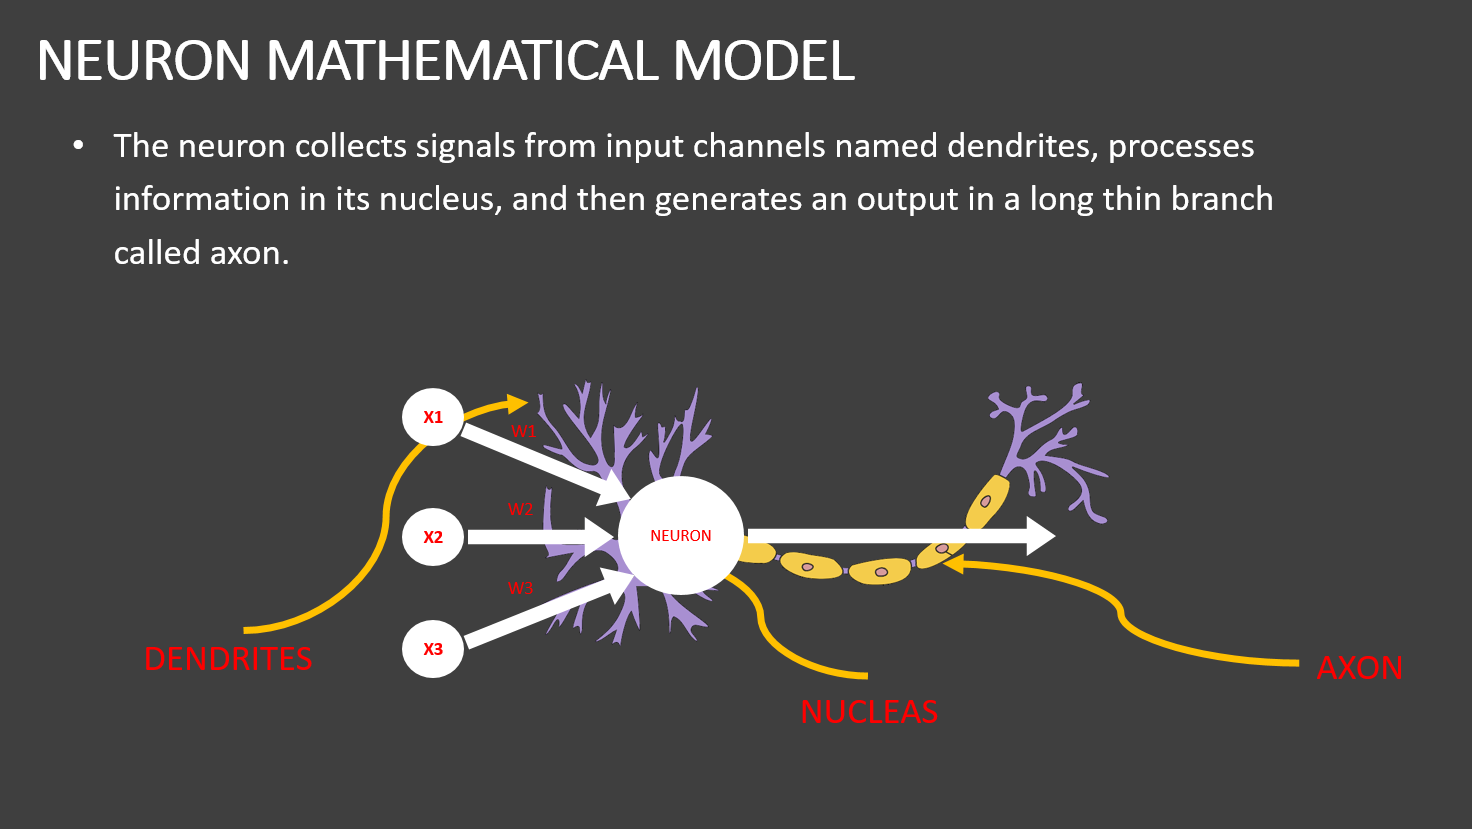

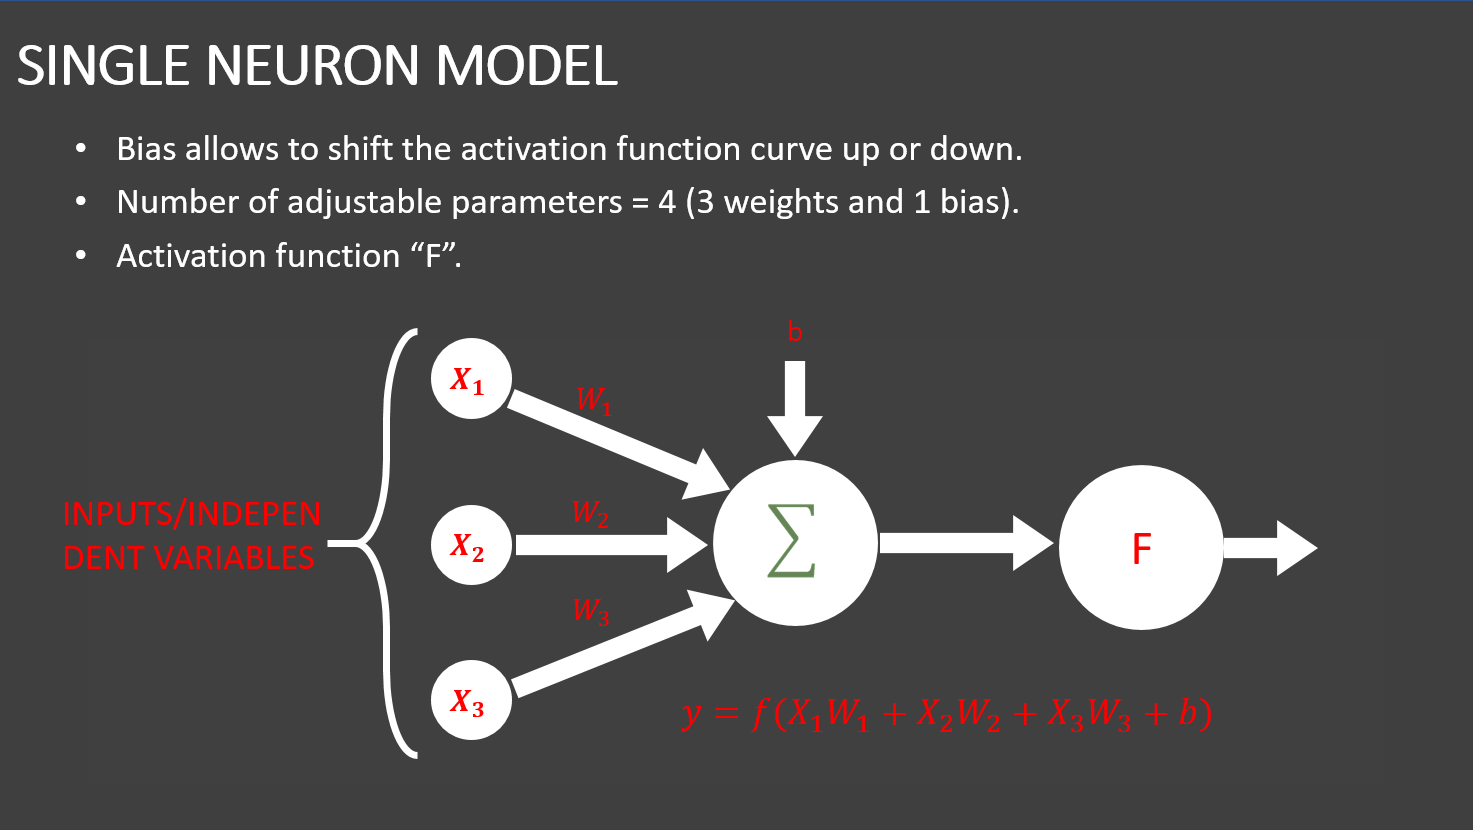

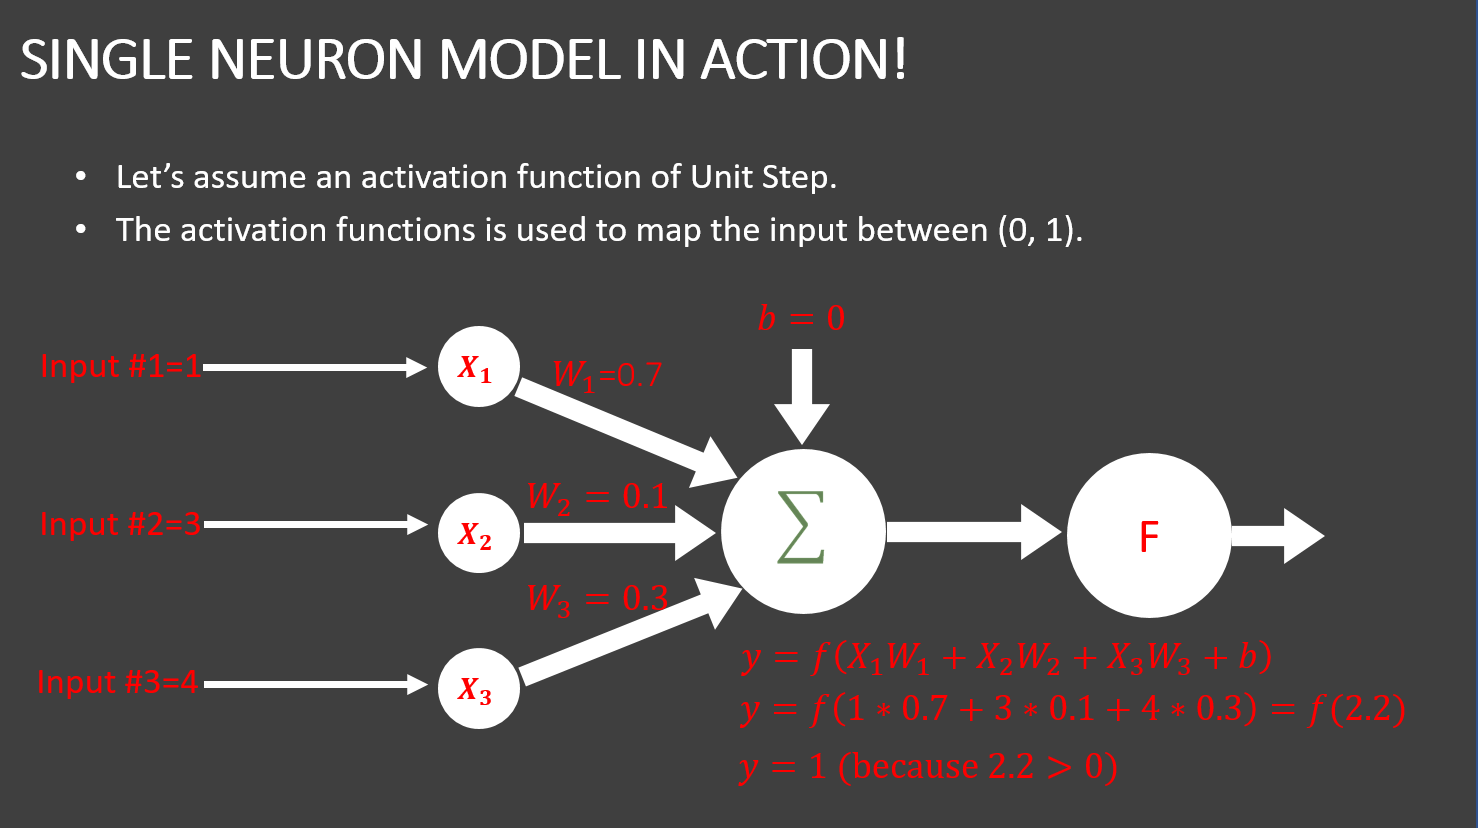

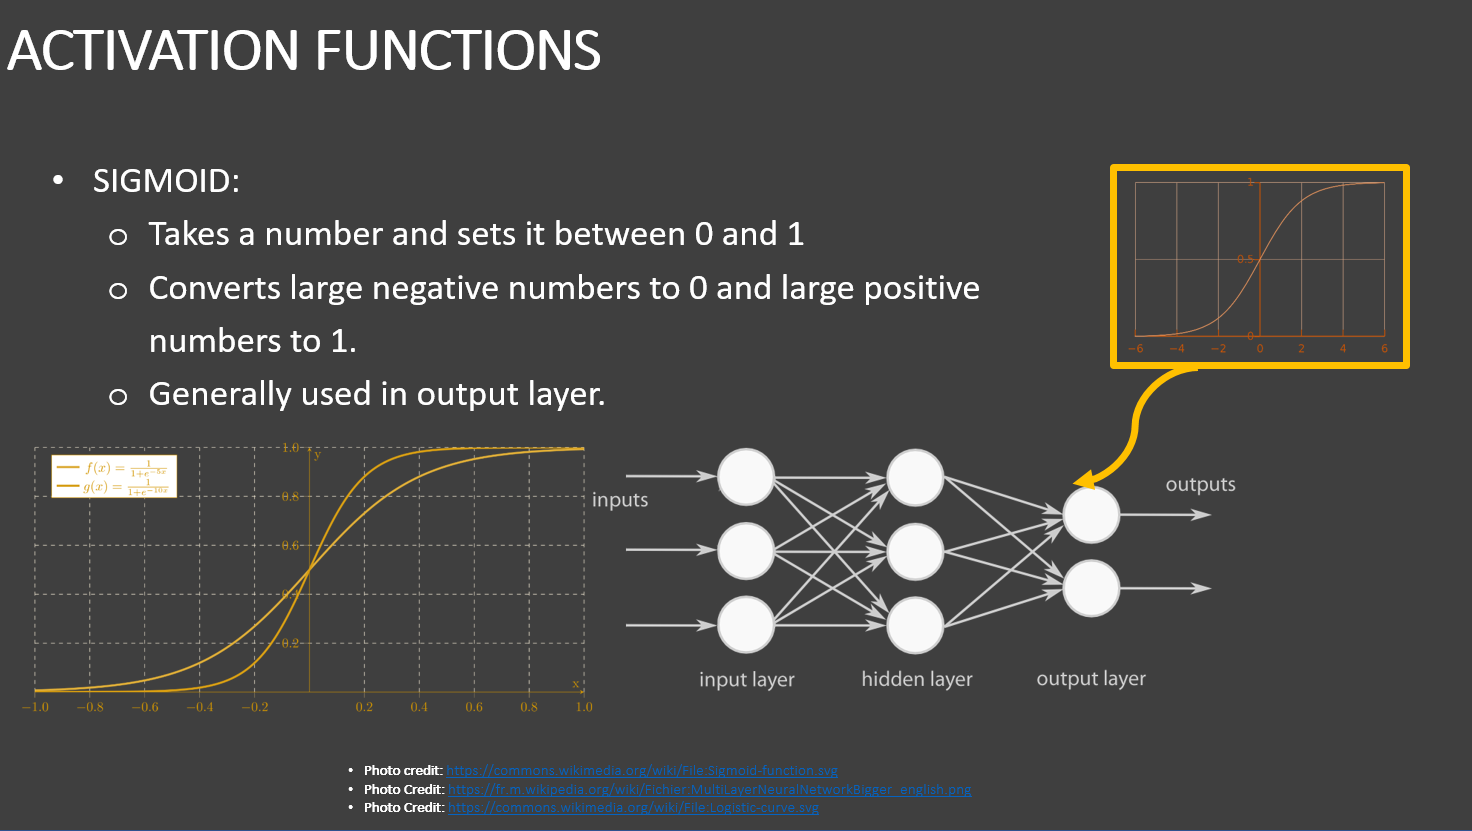

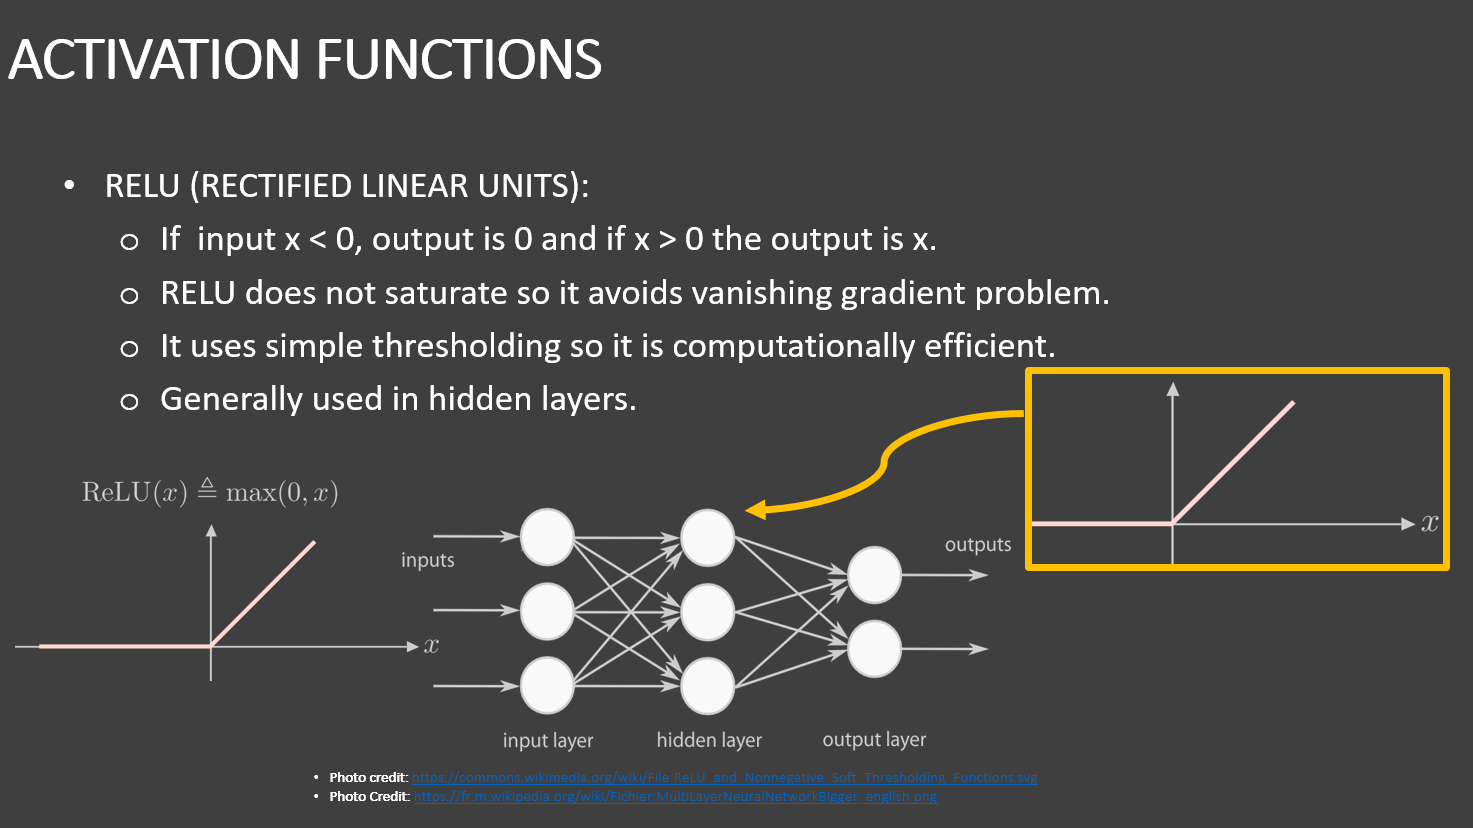

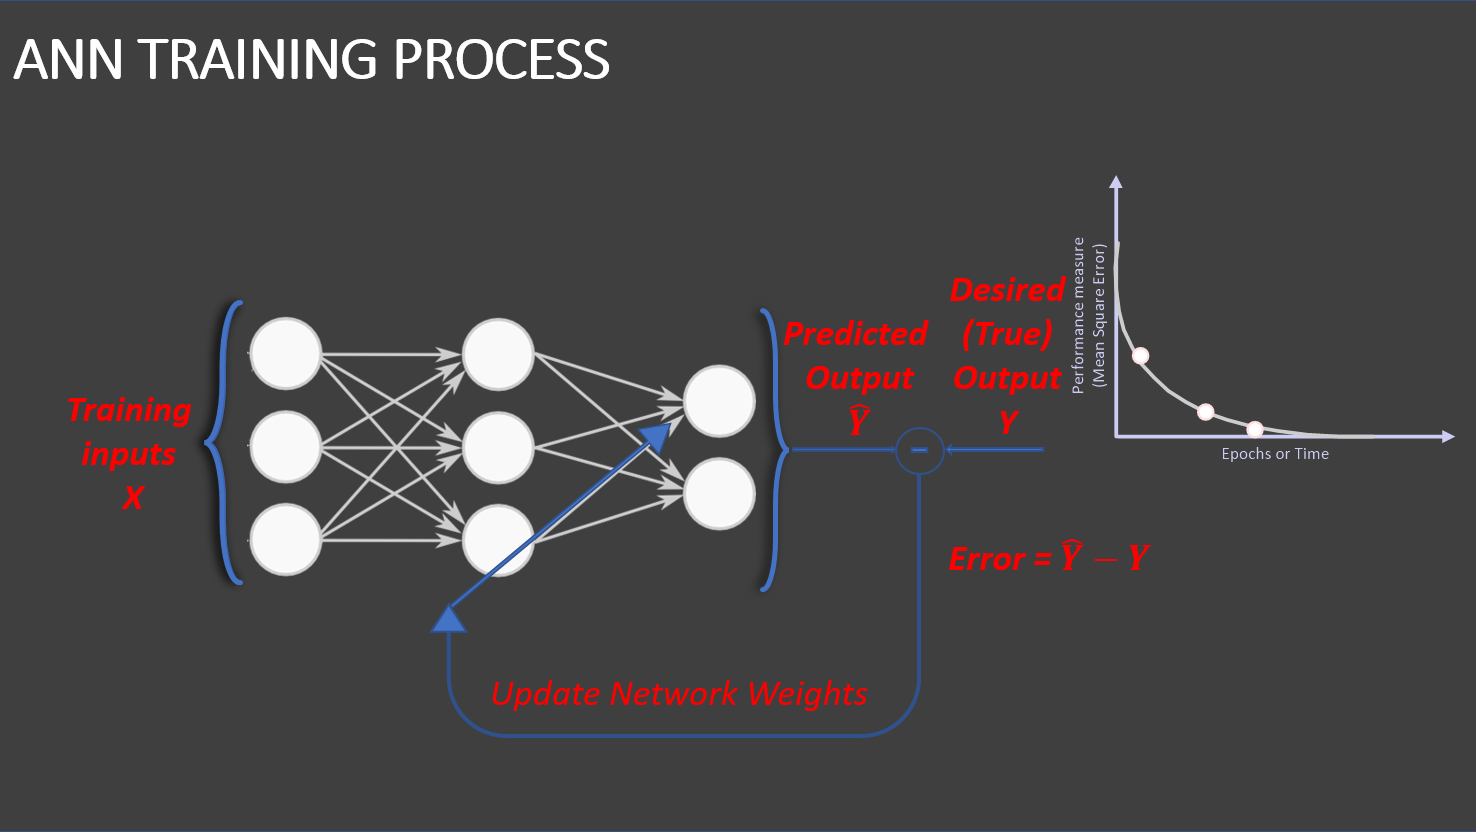

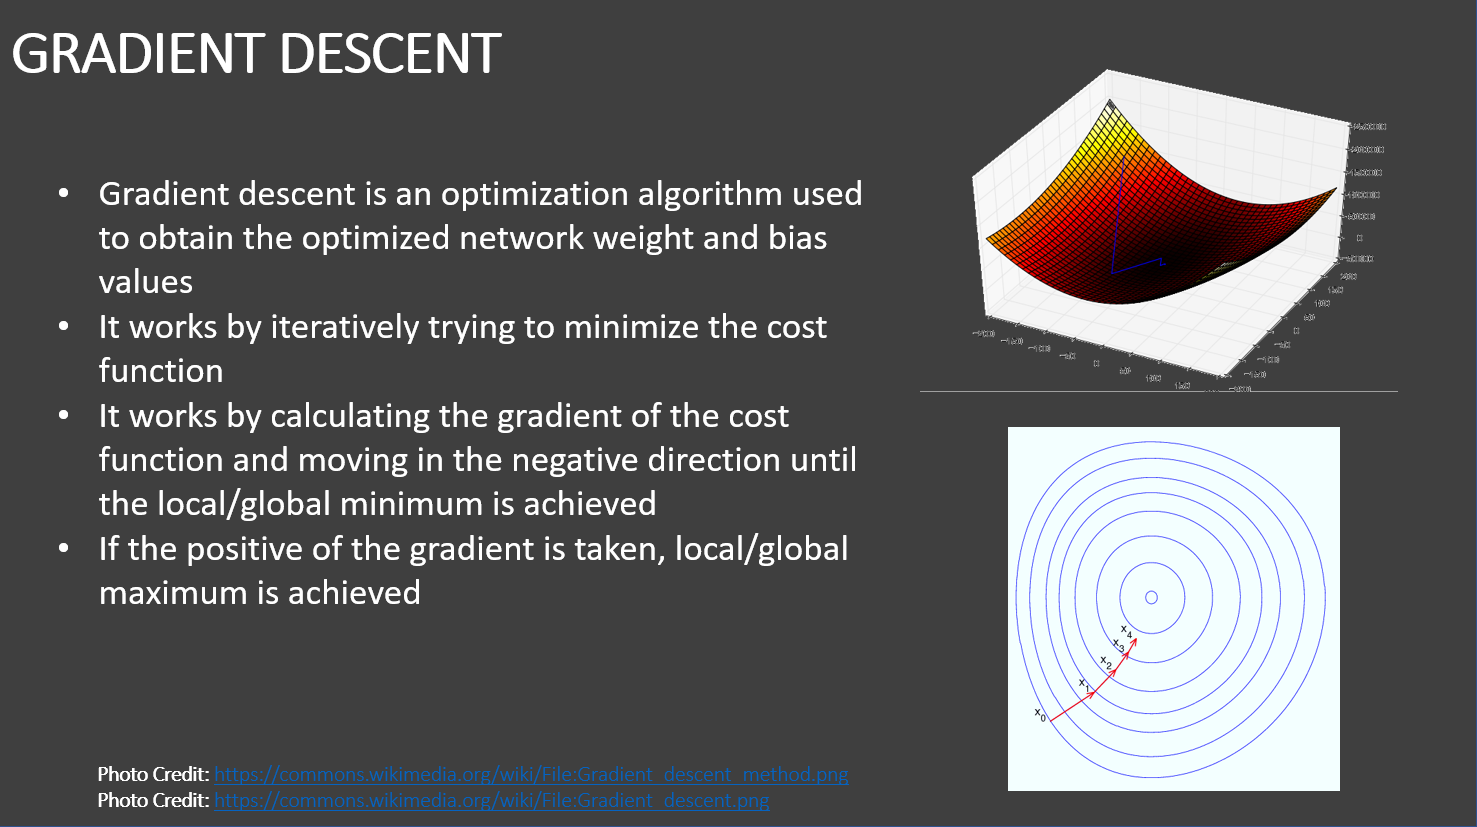

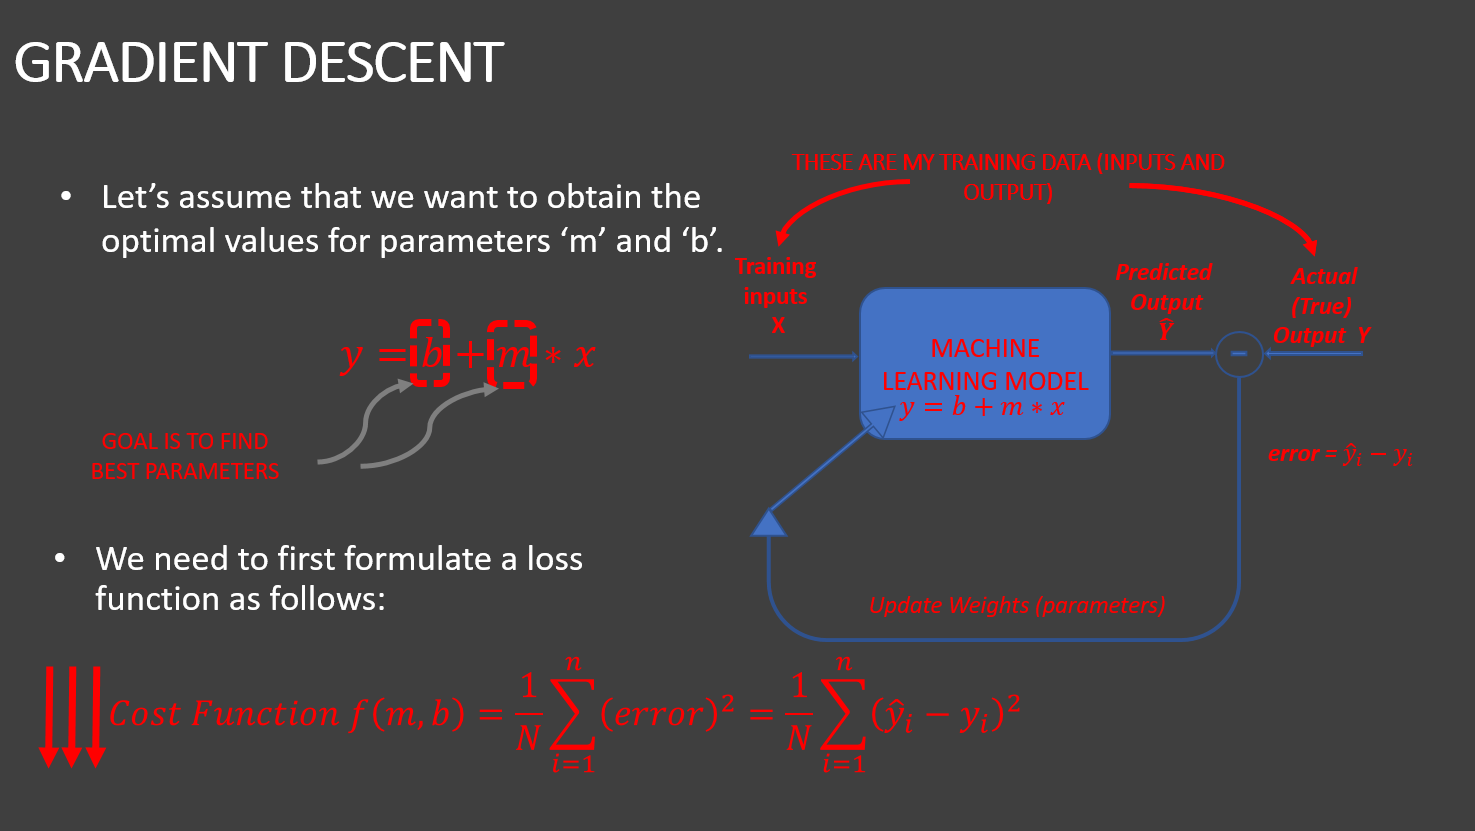

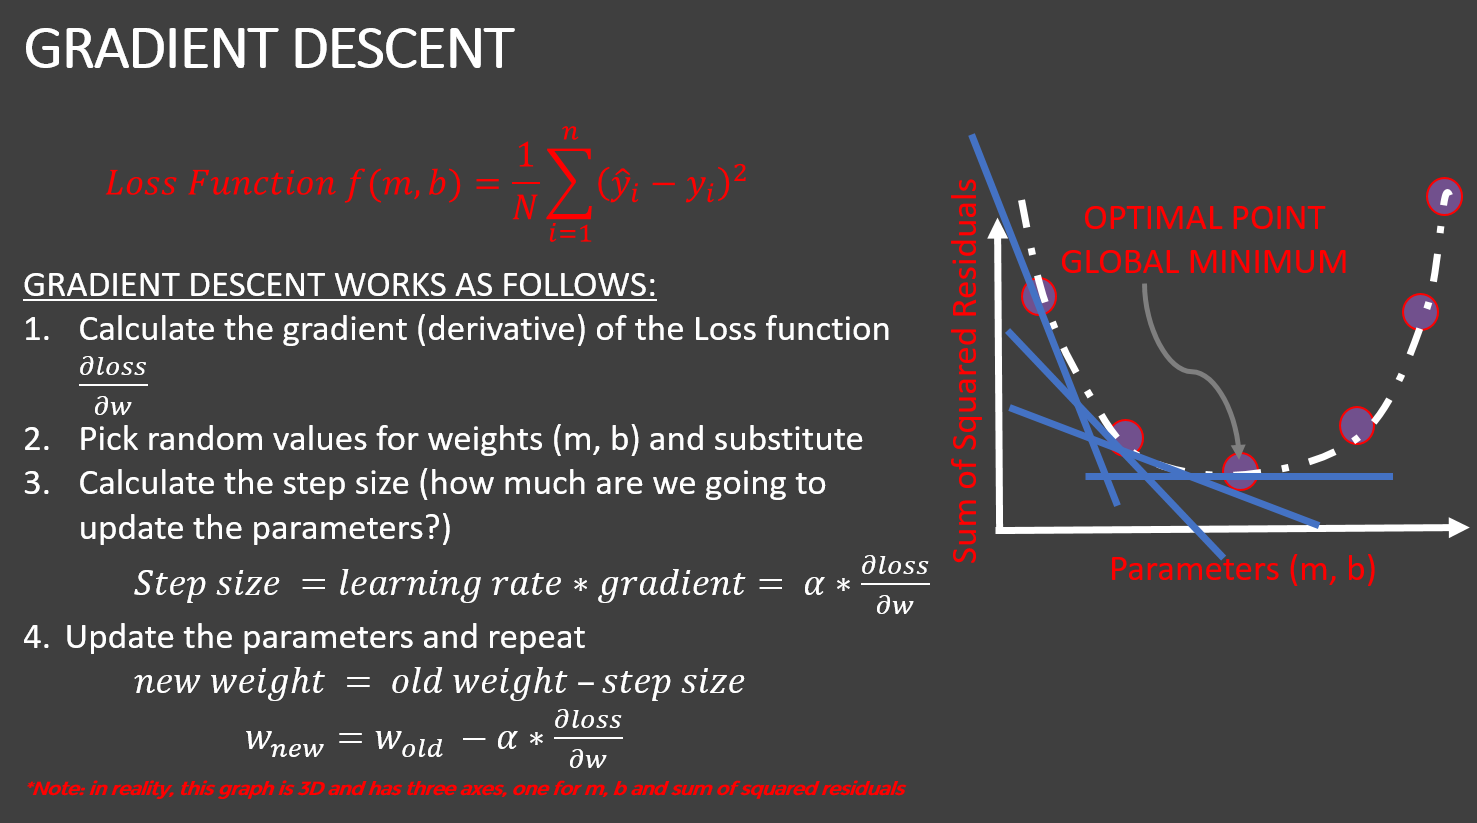

# TASK #8: TRAIN AN ARTIFICIAL NEURAL NETWORK TO PERFORM REGRESSION TASK

In [70]:
# Train an artificial neural network to perform regression task
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.001, beta_1 = 0.9, beta_2 = 0.999, epsilon = 1e-07, amsgrad = False)
ANN_model = keras.Sequential()
ANN_model.add(Dense(250, input_dim = 22, kernel_initializer='normal',activation='relu'))
ANN_model.add(Dense(500,activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(1000, activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(1000, activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(500, activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(250, activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(1, activation = 'linear'))
ANN_model.compile(loss = 'mse', optimizer = 'adam')
ANN_model.summary()

C:\Users\gianc\anaconda3\envs\py3-TF2.0\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 250)                 │           5,750 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 500)                 │         125,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 500)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1000)                │         501,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1000)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1000)                │       1,001,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1000)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 500)                 │         500,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 500)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 250)                 │         125,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 250)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │             251 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,259,251 (8.62 MB)

 Trainable params: 2,259,251 (8.62 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
history = ANN_model.fit(X_train, y_train, epochs = 5, validation_split = 0.2)

Epoch 1/5
4914/4914 ━━━━━━━━━━━━━━━━━━━━ 38s 8ms/step - loss: 0.2524 - val_loss: 0.1568
Epoch 2/5
4914/4914 ━━━━━━━━━━━━━━━━━━━━ 37s 8ms/step - loss: 0.1486 - val_loss: 0.1174
Epoch 3/5
4914/4914 ━━━━━━━━━━━━━━━━━━━━ 38s 8ms/step - loss: 0.1225 - val_loss: 0.1033
Epoch 4/5
4914/4914 ━━━━━━━━━━━━━━━━━━━━ 37s 8ms/step - loss: 0.1052 - val_loss: 0.0903
Epoch 5/5
4914/4914 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - loss: 0.0955 - val_loss: 0.0781


In [72]:
result = ANN_model.evaluate(X_test, y_test)
accuracy_ANN = 1 - result
print("Accuracy : {}".format(accuracy_ANN))

1536/1536 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0795
Accuracy : 0.9210070669651031


In [73]:
# We obtain an accuracy of 92% which is also great but not greater than decision tree regression of having 98%
# accuracy

In [74]:
history.history.keys()

dict_keys(['loss', 'val_loss'])

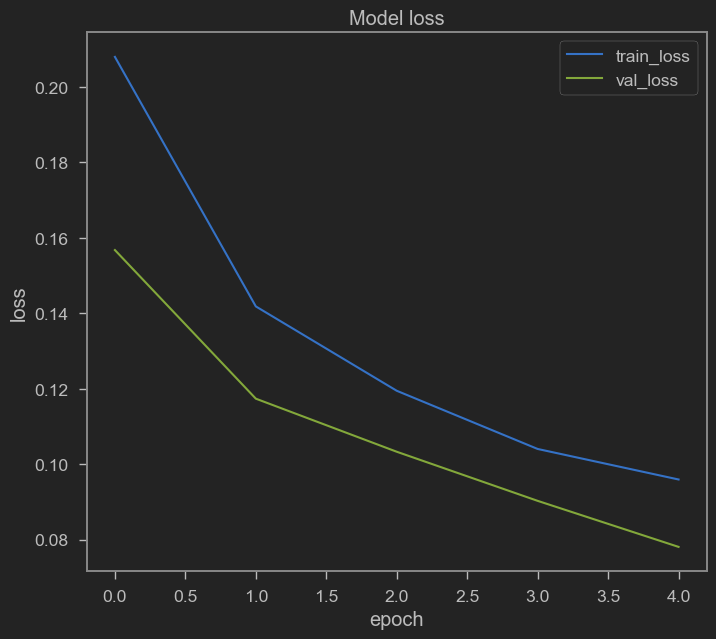

In [75]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss','val_loss'], loc = 'upper right')
plt.show()

In [76]:
# Now we have here epochs on X axis and loss on y axis. We have 5 epochs a loss. We started with a very large loss
# essentially and then over time it tends to go down until we stop the training. Note that we can actually
# dramatically improve the performance of the network. If we let it train beyond 5 epochs that we have, maybe extend
# it to 10 epochs or so, or more than that. We should be able to improve the performance of the trained model.

- **Add a dense layer with 250 neurons**
- **Print out the model summary and list the number of trainable parameters**

In [78]:
# Train an artificial neural network to perform regression task with additional dense layer
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.001, beta_1 = 0.9, beta_2 = 0.999, epsilon = 1e-07, amsgrad = False)
ANN_model = keras.Sequential()
ANN_model.add(Dense(250, input_dim = 22, kernel_initializer='normal',activation='relu'))
ANN_model.add(Dense(500,activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(1000, activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(1000, activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(500, activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(250, activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(250, activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(1, activation = 'linear'))
ANN_model.compile(loss = 'mse', optimizer = 'adam')
ANN_model.summary()

C:\Users\gianc\anaconda3\envs\py3-TF2.0\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                      │ (None, 250)                 │           5,750 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 500)                 │         125,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 500)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1000)                │         501,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 1000)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1000)                │       1,001,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 1000)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 500)                 │         500,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 500)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 250)                 │         125,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 250)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 250)                 │          62,750 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 250)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 1)                   │             251 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,322,001 (8.86 MB)

 Trainable params: 2,322,001 (8.86 MB)

 Non-trainable params: 0 (0.00 B)

In [79]:
# On our first trained ANN, we have 2.259 million parameters, now we have 2.3 million parameters. So just by adding
# a very simple line of code, we have been able to introduce additional layers with additional weights and a number
# of trainable parameters changed accordingly.

# TASK #9: COMPARE MODELS AND CALCULATE REGRESSION KPIs 


In [81]:
# From the above results, it can be seen that, decision tree model out-performs the other models. Now lets grab the
# best model of all the models the Decision Tree, without doing any tuning at all, it has been able to perform best
# with almost 99% accuracy. SO let's focus on decision trees for now.

Text(0, 0.5, 'True Values')

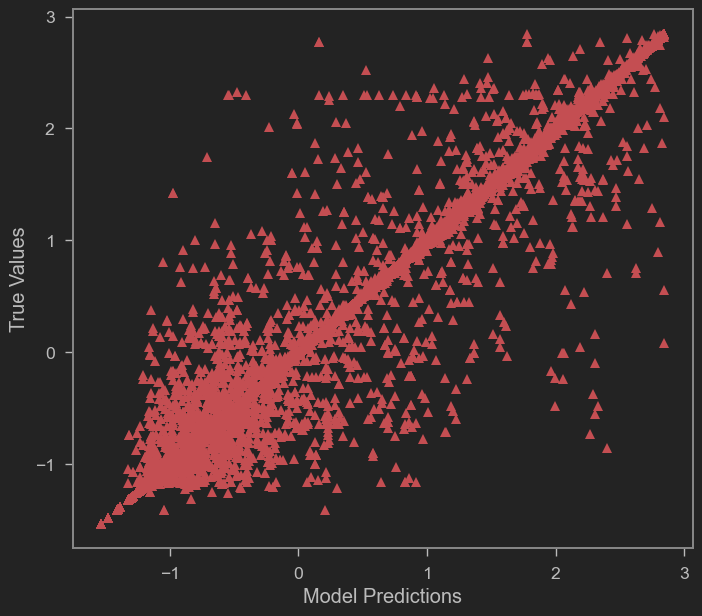

In [82]:
y_predict = DecisionTree_model.predict(X_test)
plt.plot(y_test, y_predict, "^", color = 'r')
plt.xlabel('Model Predictions')
plt.ylabel('True Values')

In [83]:
# What we see here is the plot of predicted values and the true values, and it looks like we have a nice 45 degree
# line, that means that the model predictions actually match the true values.

Text(0, 0.5, 'True Values')

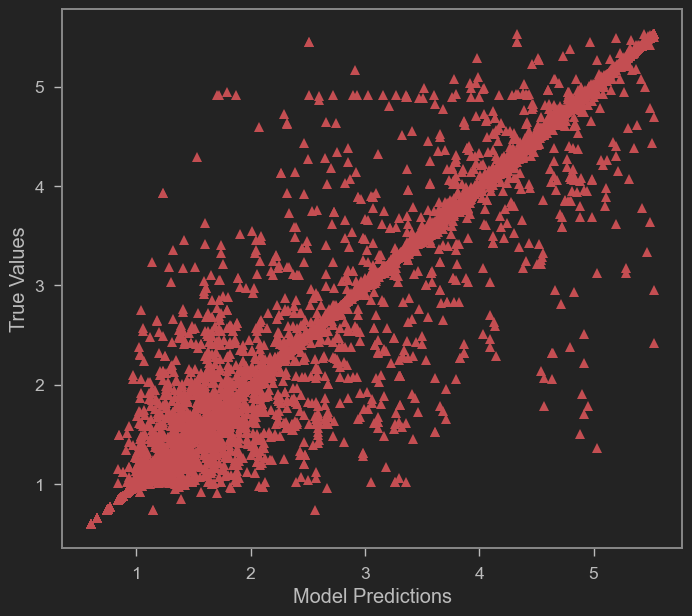

In [84]:
# Plot the same graph in its original scale
y_predict_orig = scaler_y.inverse_transform(y_predict.reshape(-1,1))
y_test_orig = scaler_y.inverse_transform(y_test.reshape(-1,1))
plt.plot(y_test_orig, y_predict_orig, "^", color = 'r')
plt.xlabel('Model Predictions')
plt.ylabel('True Values')

In [85]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from math import sqrt

k = X_test.shape[1]
n = len(X_test)
RMSE = float(format(np.sqrt(mean_squared_error(y_test_orig, y_predict_orig)),'.3f'))
MSE = mean_squared_error(y_test_orig, y_predict_orig)
MAE = mean_absolute_error(y_test_orig, y_predict_orig)
r2 = r2_score(y_test_orig, y_predict_orig)
adj_r2 = 1-(1-r2)*(n-1)/(n-k-1)

print('RMSE =',RMSE, '\nMSE =',MSE, '\nMAE =',MAE, '\nR2 =', r2, '\nAdjusted R2 =', adj_r2) 

RMSE = 0.154 
MSE = 0.02377395349265654 
MAE = 0.023502234719055635 
R2 = 0.981330034401806 
Adjusted R2 = 0.981321671935793
